# EQ/IR Double Digital: SPX × CMS10, 4 sign variants

A fixed cash payout if **both** an equity condition and a rates condition are met:

$$ V_T = N \cdot \mathbf{1}\{\eta_S\,(S_T - K) > 0\} \cdot \mathbf{1}\{\eta_R\,(R_T - B) > 0\} $$

| Variant | $\eta_S$ | $\eta_R$ | Pays when |
|---------|---------|---------|-----------|
| Above × Above | +1 | +1 | SPX above strike **and** CMS10 above barrier |
| Above × Below | +1 | -1 | SPX above strike **and** CMS10 below barrier |
| Below × Above | -1 | +1 | SPX below strike **and** CMS10 above barrier |
| Below × Below | -1 | -1 | SPX below strike **and** CMS10 below barrier |

This is the purest expression of the correlation trade. There is no optionality on either level — only on whether the two events *co-occur* — so the price is essentially a joint probability, discounted:

$$V_0 = N\,P(0,T)\; M_2\!\big(\eta_S d_2,\; \eta_R h;\; \eta_S\eta_R\rho\big)$$

**No numeraire change appears.** The payoff has no $S_T$ factor, so the $\rho\sigma_S\sqrt{T}$ shift that features in the conditional european is absent here. That makes the double digital the cleanest place to see what correlation alone does.

The four variants partition the $(S,R)$ plane, so their prices sum to $N\,P(0,T)$ — a hard identity we check below.

## Setup

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))

import numpy as np
import matplotlib.pyplot as plt
from dataclasses import replace
from scipy.stats import norm

from src.hybrid import (EQIRTrade, RateCondition, double_digital,
                        double_digital_mc)

In [2]:
# --- Trade attributes (defined inline, self-contained) ---
NOTIONAL = 20e6    # $20mm cash payout
T = 2.0

t = EQIRTrade(
    F=7200.0 * np.exp((0.045 - 0.015) * T),  # SPX forward to T
    K=7645.0,        # SPX strike, ~= the forward (ATM-forward digital)
    P0T=np.exp(-0.045 * T),
    sig_S=0.16,
    R_0=0.0410,      # 10y forward swap rate -- UNADJUSTED
    B=0.0410,        # rate barrier at the forward
    sig_R=0.0080,    # 80bp/yr normal vol
    T=T,
    rho=-0.30,
    tenor=10,
    freq=2,
)

print(f"Cash payout: ${NOTIONAL/1e6:.0f}mm")
print(f"SPX:         forward {t.F:.0f}, strike {t.K:.0f}  ({(t.F/t.K-1)*100:+.1f}% vs strike)")
print(f"CMS10:       forward swap {t.R_0:.3%}, barrier {t.B:.3%}")
print(f"             convexity-adjusted {t.R_adj:.4%}  (+{(t.R_adj-t.R_0)*1e4:.2f}bp)")
print(f"Tenor:       {t.T}y,  P(0,T) = {t.P0T:.4f}")
print(f"Vols:        sig_S={t.sig_S:.0%}, sig_R={t.sig_R*1e4:.0f}bp/yr (normal)")
print(f"Corr:        rho={t.rho}")

Cash payout: $20mm
SPX:         forward 7645, strike 7645  (+0.0% vs strike)
CMS10:       forward swap 4.100%, barrier 4.100%
             convexity-adjusted 4.1445%  (+4.45bp)
Tenor:       2.0y,  P(0,T) = 0.9139
Vols:        sig_S=16%, sig_R=80bp/yr (normal)
Corr:        rho=-0.3


## Summary table — the four sign partitions

In [3]:
quadrants = [("above", "above"), ("above", "below"),
             ("below", "above"), ("below", "below")]

eq_leg, cms_leg = t.legs()
print(f"{'Variant':<20} {'P(joint)':>10} {'P(SPX)':>9} {'P(CMS)':>9} "
      f"{'indep':>9} {'Price $mm':>11}")
print("-" * 74)
total = 0.0
for ed, cd in quadrants:
    d = double_digital(eq_leg, cms_leg, t.T, t.rho, NOTIONAL, ed, cd)
    indep = d["P_eq"] * d["P_condition"]
    total += d["price"]
    print(f"SPX {ed:<5} x CMS {cd:<5} {d['P_joint']:10.2%} {d['P_eq']:9.2%} "
          f"{d['P_condition']:9.2%} {indep:9.2%} {d['price']/1e6:11.3f}")

print("-" * 74)
print(f"{'Sum of four':<20} {'':>10} {'':>9} {'':>9} {'':>9} {total/1e6:11.3f}")
print(f"{'N * P(0,T)':<20} {'':>10} {'':>9} {'':>9} {'':>9} "
      f"{NOTIONAL*t.P0T/1e6:11.3f}")
print(f"\nPartition residual: {total - NOTIONAL*t.P0T:+.3e}")

Variant                P(joint)    P(SPX)    P(CMS)     indep   Price $mm
--------------------------------------------------------------------------
SPX above x CMS above     18.65%    45.50%    51.57%    23.46%       3.408
SPX above x CMS below     26.85%    45.50%    48.43%    22.04%       4.909
SPX below x CMS above     32.92%    54.50%    51.57%    28.10%       6.017
SPX below x CMS below     21.58%    54.50%    48.43%    26.39%       3.944
--------------------------------------------------------------------------
Sum of four                                                        18.279
N * P(0,T)                                                         18.279

Partition residual: +0.000e+00


**Read.** Compare `P(joint)` with `indep` = $P(\text{SPX})\times P(\text{CMS})$: the gap is entirely correlation. With $\rho = -0.30$ the "same direction" quadrants (above×above, below×below) price *below* independence, and the "opposite direction" ones above it. The four prices sum to $N\,P(0,T)$ to machine precision, because the quadrants partition the sample space.

## Payoff at maturity

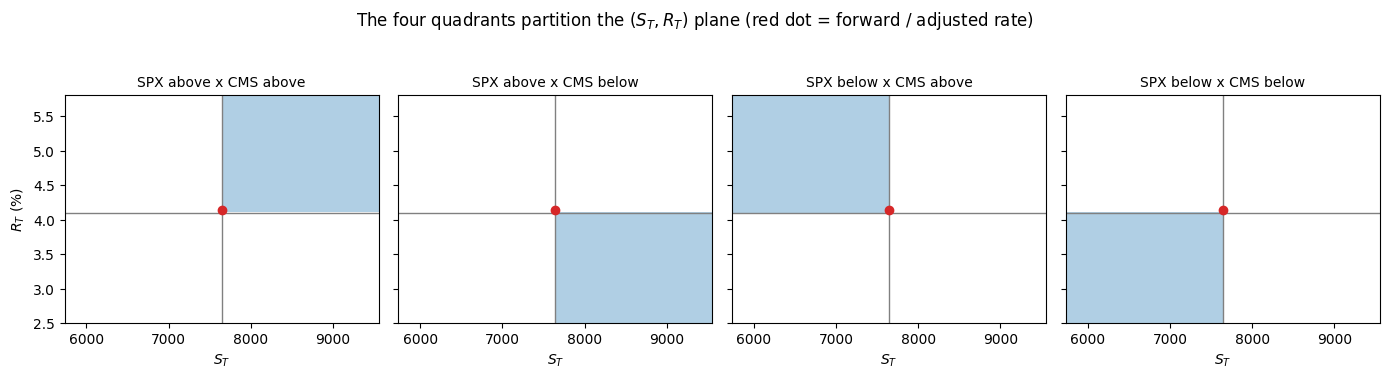

In [4]:
fig, axes = plt.subplots(1, 4, figsize=(14, 3.6), sharey=True)
s_grid = np.linspace(t.F*0.75, t.F*1.25, 220)
r_grid = np.linspace(0.025, 0.058, 220)
SS, RR = np.meshgrid(s_grid, r_grid)

for ax, (ed, cd) in zip(axes, quadrants):
    eta_S = 1 if ed == "above" else -1
    eta_R = 1 if cd == "above" else -1
    pays = ((eta_S*(SS - t.K) > 0) & (eta_R*(RR - t.B) > 0)).astype(float)
    ax.contourf(SS, RR*100, pays, levels=[0.5, 1.5], colors=["C0"], alpha=0.35)
    ax.axvline(t.K, color="grey", linewidth=1)
    ax.axhline(t.B*100, color="grey", linewidth=1)
    ax.plot(t.F, t.R_adj*100, "o", color="C3", markersize=6)
    ax.set_title(f"SPX {ed} x CMS {cd}", fontsize=10)
    ax.set_xlabel("$S_T$")
axes[0].set_ylabel("$R_T$ (%)")
fig.suptitle("The four quadrants partition the $(S_T, R_T)$ plane "
             "(red dot = forward / adjusted rate)", y=1.04)
plt.tight_layout(); plt.show()

## Closed form and Monte Carlo

In [5]:
print(f"{'Variant':<20} {'Closed form':>13} {'Monte Carlo':>13} "
      f"{'MC 95% CI ($mm)':>26} {'diff/SE':>9}")
print("-" * 86)
for ed, cd in quadrants:
    cf = double_digital(eq_leg, cms_leg, t.T, t.rho, NOTIONAL, ed, cd)["price"]
    mc = double_digital_mc(eq_leg, cms_leg, t.T, t.rho, NOTIONAL, ed, cd,
                           n_paths=1_000_000, seed=11)
    lo, hi = mc["ci95"]
    print(f"SPX {ed:<5} x CMS {cd:<5} {cf/1e6:13.4f} {mc['price']/1e6:13.4f} "
          f"  [{lo/1e6:9.4f}, {hi/1e6:9.4f}] "
          f"{abs(cf-mc['price'])/mc['std_error']:9.2f}")

Variant                Closed form   Monte Carlo            MC 95% CI ($mm)   diff/SE
--------------------------------------------------------------------------------------


SPX above x CMS above        3.4084        3.4134   [   3.3995,    3.4274]      0.71
SPX above x CMS below        4.9086        4.8999   [   4.8841,    4.9158]      1.07
SPX below x CMS above        6.0175        6.0185   [   6.0017,    6.0353]      0.12
SPX below x CMS below        3.9441        3.9467   [   3.9320,    3.9615]      0.34


## Cega — sign flips with $\eta_S\eta_R$

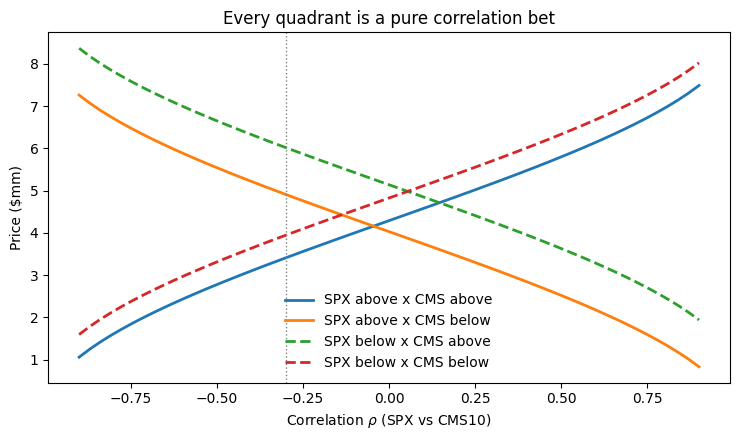

Variant                rho=-0.6      rho=0   rho=+0.6   cega $k/1%
------------------------------------------------------------------
SPX above x CMS above      2.429      4.289      6.142         30.3
SPX above x CMS below      5.888      4.028      2.175        -30.3
SPX below x CMS above      6.997      5.137      3.284        -30.3
SPX below x CMS below      2.965      4.825      6.678         30.3


In [6]:
rhos = np.linspace(-0.9, 0.9, 60)
fig, ax = plt.subplots(figsize=(7.5, 4.5))
for ed, cd in quadrants:
    ys = [double_digital(eq_leg, cms_leg, t.T, r, NOTIONAL, ed, cd)["price"]/1e6
          for r in rhos]
    style = "-" if ed == "above" else "--"
    ax.plot(rhos, ys, style, linewidth=2, label=f"SPX {ed} x CMS {cd}")
ax.axvline(t.rho, color="grey", linestyle=":", linewidth=1)
ax.set_xlabel(r"Correlation $\rho$ (SPX vs CMS10)")
ax.set_ylabel("Price ($mm)")
ax.set_title("Every quadrant is a pure correlation bet")
ax.legend(frameon=False)
plt.tight_layout(); plt.show()

print(f"{'Variant':<20} {'rho=-0.6':>10} {'rho=0':>10} {'rho=+0.6':>10} {'cega $k/1%':>12}")
print("-" * 66)
for ed, cd in quadrants:
    px = [double_digital(eq_leg, cms_leg, t.T, r, NOTIONAL, ed, cd)["price"]
          for r in (-0.6, 0.0, 0.6)]
    up = double_digital(eq_leg, cms_leg, t.T, t.rho+0.01, NOTIONAL, ed, cd)["price"]
    dn = double_digital(eq_leg, cms_leg, t.T, t.rho-0.01, NOTIONAL, ed, cd)["price"]
    print(f"SPX {ed:<5} x CMS {cd:<5} {px[0]/1e6:10.3f} {px[1]/1e6:10.3f} "
          f"{px[2]/1e6:10.3f} {(up-dn)/2/1e3:12.1f}")

**Read.** Cega sign is $\eta_S\eta_R$: the "aligned" quadrants gain from positive correlation, the "crossed" ones lose. The four cegas cancel in pairs, which they must — the total is $N\,P(0,T)$, a constant independent of $\rho$.

Because there is no numeraire change and no optionality on level, this is as close to a pure correlation instrument as the product set gets.

## Joint exercise probability surface

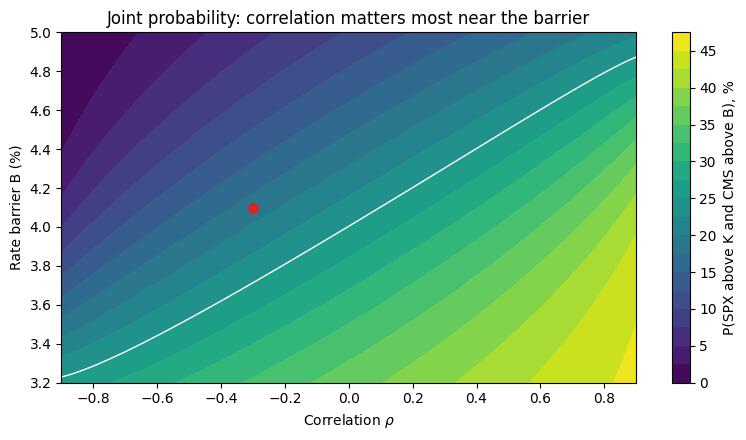

In [7]:
rho_grid = np.linspace(-0.9, 0.9, 60)
barrier_grid = np.linspace(0.032, 0.050, 60)
Z = np.zeros((len(barrier_grid), len(rho_grid)))
for i, B in enumerate(barrier_grid):
    leg = RateCondition.from_forward_swap(R_0=t.R_0, B=B, sig_R=t.sig_R,
                                          T=t.T, tenor=t.tenor, freq=t.freq)
    for j, r in enumerate(rho_grid):
        Z[i, j] = double_digital(eq_leg, leg, t.T, r, 1.0,
                                 "above", "above")["P_joint"]

fig, ax = plt.subplots(figsize=(8, 4.5))
cs = ax.contourf(rho_grid, barrier_grid*100, Z*100, levels=18, cmap="viridis")
ax.contour(rho_grid, barrier_grid*100, Z*100, levels=[25, 50],
           colors="white", linewidths=1)
ax.plot(t.rho, t.B*100, "o", color="C3", markersize=7)
fig.colorbar(cs, ax=ax, label="P(SPX above K and CMS above B), %")
ax.set_xlabel(r"Correlation $\rho$"); ax.set_ylabel("Rate barrier B (%)")
ax.set_title("Joint probability: correlation matters most near the barrier")
plt.tight_layout(); plt.show()

**Read.** The correlation gradient is steepest where both conditions are near 50/50. Push the rate barrier far from the forward and the joint probability collapses toward $P(\text{SPX})\times 0$ or $P(\text{SPX})\times 1$ — correlation stops mattering because one leg is nearly deterministic. Structurers exploit this: an out-of-the-money rate barrier buys cheapness but gives up most of the correlation view.

## Convexity in a digital

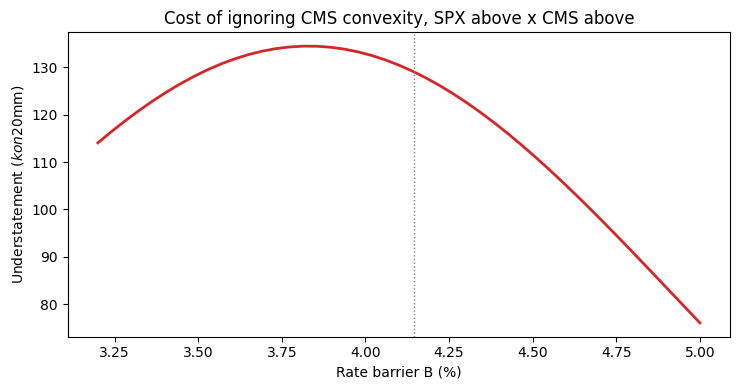

At B=4.10%: adjusted $3.4084mm vs unadjusted $3.2779mm  ->  $130.5k understated (3.83%)


In [8]:
barriers = np.linspace(0.032, 0.050, 45)
adj, naive = [], []
for B in barriers:
    leg_adj = RateCondition.from_forward_swap(R_0=t.R_0, B=B, sig_R=t.sig_R,
                                              T=t.T, tenor=t.tenor, freq=t.freq)
    leg_raw = RateCondition(R_adj=t.R_0, B=B, sig_R=t.sig_R)
    adj.append(double_digital(eq_leg, leg_adj, t.T, t.rho, NOTIONAL,
                              "above", "above")["price"]/1e6)
    naive.append(double_digital(eq_leg, leg_raw, t.T, t.rho, NOTIONAL,
                                "above", "above")["price"]/1e6)
adj, naive = np.array(adj), np.array(naive)

fig, ax = plt.subplots(figsize=(7.5, 4))
ax.plot(barriers*100, (adj-naive)*1e6/1e3, color="C3", linewidth=2)
ax.axvline(t.R_adj*100, color="grey", linestyle=":", linewidth=1)
ax.set_xlabel("Rate barrier B (%)")
ax.set_ylabel("Understatement ($k on $20mm)")
ax.set_title("Cost of ignoring CMS convexity, SPX above x CMS above")
plt.tight_layout(); plt.show()

i = int(np.argmin(abs(barriers - t.B)))
print(f"At B={barriers[i]:.2%}: adjusted ${adj[i]:.4f}mm vs unadjusted "
      f"${naive[i]:.4f}mm  ->  ${(adj[i]-naive[i])*1e3:.1f}k understated "
      f"({(adj[i]-naive[i])/adj[i]:.2%})")

**Read.** The digital is *more* sensitive to the convexity adjustment than the conditional european, in relative terms: the whole payout hinges on which side of the barrier the rate lands, so a shift in the rate's mean translates almost directly into a shift in the payout probability. There is no equity optionality to dilute it.

## Takeaways

1. **The four quadrants sum to $N\,P(0,T)$** to machine precision. It is the cheapest possible regression test on the sign conventions, and it holds for rates exactly as it does for FX.
2. **No numeraire change appears**, since the payoff has no $S_T$ factor. The $\rho\sigma_S\sqrt{T}$ shift is absent — this is the cleanest place to isolate correlation.
3. **Cega sign is $\eta_S\eta_R$**, and the four cegas cancel in pairs.
4. **Correlation matters most when both legs are near 50/50.** Moving the rate barrier out of the money cheapens the structure but throws away the correlation exposure that motivated it.
5. **Convexity bites harder here than in the conditional european**, relatively speaking — there is no equity optionality to dilute a shift in the rate's mean.